**Repository review — 7 September 2026.** Outputs below are preserved from experiment commit 93676de; the updated source has not been re-executed on the original raw data. New safeguards invalidate the old code freeze. Restore the hash-matched inputs and run the experiment driver before Run All. Four historical benchmark quality-exposure exports disagree with summary tables; see REVIEW.md. Return and risk results are unaffected by that export discrepancy.

# Portfolio optimization — unified experimental comparison

## TL;DR

All five primary strategies are compared on identical daily returns and the same test window. This notebook reconciles saved results, separates predictive improvements from portfolio improvements, and develops a defensible article narrative without assuming that complexity must win.

**Observed result:** Pipeline 1 has the highest Sharpe ratio among the optimized primary strategies. The quality layer increases diversification and reduces turnover but lowers return. CatBoost improves relative risk forecasting while adding little portfolio value; a historical-risk control remains competitive. Additional complexity does not establish general dominance on this sample.

In [1]:
from pathlib import Path
import os, sys, json, copy, warnings, tempfile
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "portfolio-mpl"))
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
# pandas 2.x / NumPy 2.4 emit this unrelated compatibility deprecation.
warnings.filterwarnings("ignore", message="The 'generic' unit for NumPy timedelta is deprecated.*", category=DeprecationWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from portfolio_research.workflow import *
from portfolio_research.features import prediction_diagnostics, forecast_risk, FEATURE_SETS
from portfolio_research.presentation import *
setup()
print({"python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__, "project": str(ROOT)})

## Context & Methods

The primary baseline is **constrained Ledoit–Wolf global minimum variance (GMV)** within the Markowitz framework. It is not a Gaussian-mixture model (GMM). The regime extension uses a **two-state Gaussian hidden Markov model (HMM)**, relabelled calm/stress by its volatility state means. Calm/stress need not coincide with bull/bear returns.

The original frozen implementation settings are retained across the main comparison: **252 prior trading sessions, monthly rebalancing, long only, fully invested, 15% maximum target weight, and 10 basis points per dollar traded**. Keeping these settings fixed isolates the incremental information layers. They are inherited controls, not claimed to be optimal after correcting the old backtest.

- **Train, 2000–2016:** rolling covariance/HMM estimation; CatBoost training snapshots begin in 2010 because historical SEC XBRL coverage is sparse before then.
- **Validation, 2017–2020:** select only new quality/ML settings using the baseline risk score: volatility 30%, CVaR95 25%, drawdown 20%, turnover 10%, HHI 10%, Sharpe 5% (reverse-ranked).
- **Test, 2021–2026-02-20:** a common evaluation window after freezing all new settings. Rolling estimators and annual CatBoost refits may learn from earlier, fully observed test history, as a live strategy would; future labels and test-dependent parameter choices are forbidden.

### Key Assumptions

1. Signals end strictly before the return they earn. Fundamental facts have an additional one-business-day publication embargo and must already be available at the actual previous trading close. Close-only data imply idealized execution at the previous close; auction delays, overnight implementation and market impact are not simulated.
2. Holdings **drift every day** between scheduled rebalances. Two-sided L1 turnover is measured against drifted holdings. Costs reduce capital multiplicatively: `net = (1 - cost) * (1 + gross) - 1`. Initial investment costs are included; terminal liquidation is not imposed.
3. Sortino uses the baseline definition: annualized mean divided by annualized root-mean-square negative returns, with a zero required return. All return/risk tables use net daily simple returns and 252 sessions/year. VaR/CVaR are daily positive loss magnitudes, not annualized estimates. Maximum drawdown includes initial wealth of 1.
4. Security caps apply at rebalancing; holdings may drift above the cap between trades. Cash yield, taxes, borrowing and capacity constraints are outside this fully invested research protocol.
5. The supplied 50 stocks were selected using full-history coverage and alphabetical tie-breaking. Historical delistings and index membership are missing. **Survivorship and universe-selection bias remain.** The data represent a narrow US equity sample, not an emerging market.
6. The original baseline notebook already exposed test results. This test is held out for the **new** hyperparameter choices; it is not a pristine preregistered replication. Previously reported numbers are superseded by the common corrected engine.

## Data

### Load executed results and their frozen provenance

In [2]:
spec = json.loads((ROOT / "artifacts/frozen_spec.json").read_text())
manifest = json.loads((ROOT / "artifacts/run_manifest.json").read_text())
assert spec["code_hashes"] == code_hashes(), "Implementation differs from the frozen experiment."
prices, returns, splits, split_summary, price_hashes = load_prices()
assert spec["input_hashes"] == price_hashes
results = {name: load_result(name, "test") for name in LABELS}
validation_results = {name: load_result(name, "validation") for name in LABELS}
for result in results.values():
    validate_result(result)
    assert result.returns.index.equals(splits["test"])
test_table = metric_table(results)
validation_table = metric_table(validation_results)
display(split_summary)
display(pd.DataFrame({"parameter": ["Quality strength", "CatBoost depth", "Trees", "ML risk strength", "Test days"],
                      "value": [spec["quality_strength"], spec["ml"]["depth"], spec["ml"]["iterations"], spec["ml"]["ml_strength"], len(splits["test"])]}))
print("All strategies share", len(splits["test"]), "test observations and", len(results["baseline"].target_weights), "rebalance dates.")

,start,end,days,assets,rows
split,,,,,
train,2000-01-03,2016-12-30,4277,50,213850
validation,2017-01-03,2020-12-31,1007,50,50350
test,2021-01-04,2026-02-20,1289,50,64450


,parameter,value
0,Quality strength,1.00
1,CatBoost depth,4.00
2,Trees,300.00
3,ML risk strength,0.25
4,Test days,1289.00


### Reconcile compact tables to full daily artifacts

Metrics are recomputed from stored daily paths and weights. The comparison refuses stale or mismatched source prices, code versions or dates. Company-quality exposure is calculated below directly from the common fundamental panel; it is not needed by the price-only control notebooks.

In [3]:
recorded = pd.read_csv(ROOT / "artifacts/tables/test_metrics.csv", index_col=0)
reconcile_columns = [x for x in recorded.columns if x != "Average Portfolio Quality"]
error = (test_table[reconcile_columns] - recorded[reconcile_columns]).abs().max().max()
assert error < 1e-9
print("Maximum absolute reconciliation error:", error)
print("Empirical tail sample sizes:", {"95%": int(np.ceil(len(splits["test"])*.05)), "99%": int(np.ceil(len(splits["test"])*.01))})
print("Data selection caveat:", spec["historical_test_exposure"])

## Results

### Validation development results

These observations were used to choose the new layer strengths. They are not independent evidence of superiority.

In [4]:
display(styled(validation_table[METRIC_COLUMNS]))

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
equal_weight,18.76%,21.94%,0.895,1.236,38.03%,3.49%,6.50%,0.846,50.000
baseline,15.42%,18.31%,0.876,1.213,33.51%,2.82%,5.77%,3.302,12.989
pipeline1,16.31%,18.44%,0.912,1.272,32.07%,2.81%,5.74%,4.526,11.567
pipeline2,15.94%,18.27%,0.901,1.250,32.90%,2.84%,5.69%,3.365,17.478
pipeline3,15.94%,18.27%,0.901,1.249,32.96%,2.84%,5.69%,3.315,17.950


### Main test table

CAGR and volatility are annualized; CVaR is a daily loss magnitude. All values are net of the same 10 bps trading-cost model.

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
equal_weight,12.11%,16.85%,0.763,1.102,20.72%,2.41%,3.78%,0.833,50.000
baseline,9.16%,13.15%,0.733,1.043,18.63%,1.86%,2.88%,3.235,12.408
pipeline1,9.68%,13.04%,0.774,1.102,18.23%,1.84%,2.84%,4.297,11.585
pipeline2,8.04%,13.10%,0.656,0.932,17.88%,1.84%,2.88%,3.252,17.115
pipeline3,8.04%,13.08%,0.656,0.933,17.78%,1.83%,2.87%,3.179,17.628


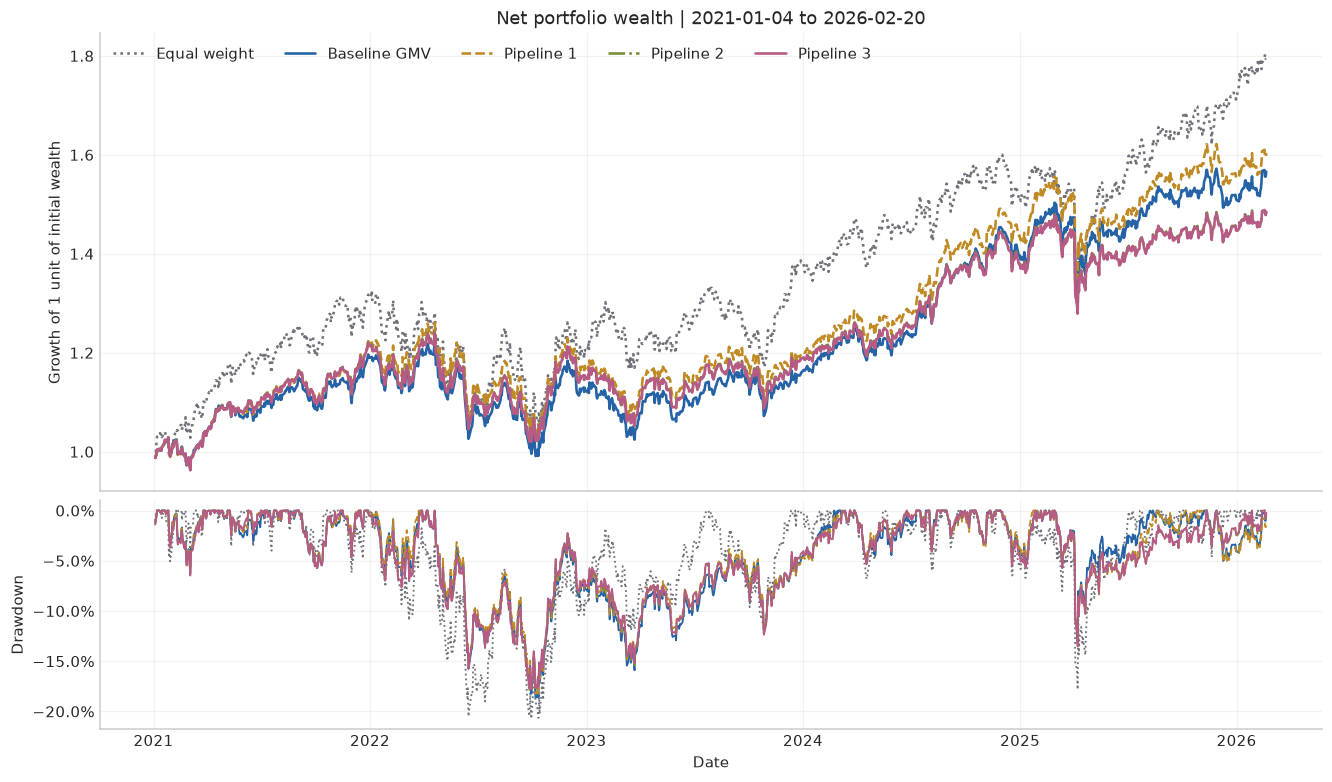

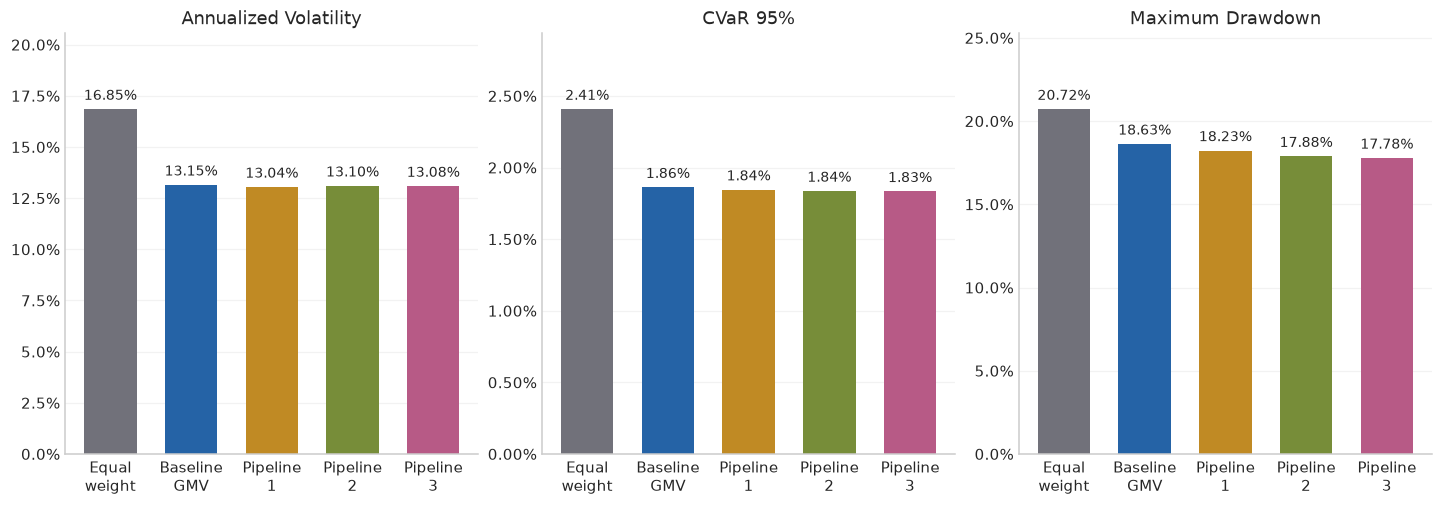

In [5]:
display(styled(test_table[METRIC_COLUMNS]))
test_table.to_csv(ROOT / "artifacts/tables/comparison_recomputed_test_metrics.csv")
performance_plot(results, "comparison_test_performance")
risk_plot(test_table, "comparison_test_risk")

### Reading the metrics

Lower volatility, CVaR and drawdown indicate less realized risk. Higher CAGR/Sharpe/Sortino indicate greater realized reward or reward per unit of risk. Turnover is the two-sided traded fraction per year, HHI is target-weight concentration, and effective breadth is `1 / HHI`. The sum of daily cost fractions is an implementation diagnostic, not the exact compounded drag on terminal wealth. Tables retain the baseline metric names and add implementation audits.

In [6]:
display(styled(test_table[["Cumulative Return", "VaR 95%", "VaR 99%", "Calmar", "Drawdown Duration", "Total Transaction Costs", "Average HHI", "Average Active Positions", "Average Maximum Weight", "Mean Target L1 Change", "Solver Failures", "HMM Fallbacks"]]))

,Cumulative Return,VaR 95%,VaR 99%,Calmar,Drawdown Duration,Total Transaction Costs,Average HHI,Average Active Positions,Average Maximum Weight,Mean Target L1 Change,Solver Failures,HMM Fallbacks
equal_weight,79.44%,1.65%,2.90%,0.585,387.000,0.43%,2.00%,50.000,2.00%,0.000,0.000,0.000
baseline,56.58%,1.29%,2.08%,0.492,469.000,1.65%,8.49%,20.065,13.70%,0.249,0.000,0.000
pipeline1,60.39%,1.30%,2.02%,0.531,471.000,2.20%,9.00%,18.984,14.01%,0.337,0.000,0.000
pipeline2,48.51%,1.28%,2.07%,0.450,474.000,1.66%,6.18%,27.694,11.48%,0.253,0.000,0.000
pipeline3,48.51%,1.27%,2.07%,0.452,474.000,1.63%,6.01%,28.710,11.31%,0.247,0.000,0.000


### Incremental changes: does each added layer help?

Negative changes favor the newer strategy for risk, costs and concentration; positive changes favor it for returns and effective breadth. The separate equal-weight reference answers whether optimization adds value relative to naive diversification.

In [7]:
pairs = [("baseline", "pipeline1"), ("pipeline1", "pipeline2"), ("pipeline2", "pipeline3")]
incremental = pd.DataFrame({f"{LABELS[b]} minus {LABELS[a]}": test_table.loc[b, METRIC_COLUMNS]-test_table.loc[a, METRIC_COLUMNS] for a,b in pairs}).T
display(styled(incremental))
incremental.to_csv(ROOT / "artifacts/tables/test_incremental_differences.csv")

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
Pipeline 1 minus Baseline GMV,0.51%,-0.10%,0.041,0.059,-0.40%,-0.02%,-0.05%,1.062,-0.822
Pipeline 2 minus Pipeline 1,-1.64%,0.06%,-0.118,-0.170,-0.35%,-0.01%,0.05%,-1.045,5.530
Pipeline 3 minus Pipeline 2,0.00%,-0.02%,0.001,0.001,-0.10%,-0.00%,-0.01%,-0.073,0.513


### Statistical uncertainty and block-length sensitivity

Paired blocks use the same sampled dates for both strategies. These 95% intervals condition on the selected strategies and this dataset. They do not correct for repeated model search, familywise comparisons, survivorship bias or an already exposed test. Bootstrap drawdown intervals are especially sensitive to synthetic block ordering.

In [8]:
bootstrap = pd.read_csv(ROOT / "artifacts/tables/test_paired_bootstrap.csv")
primary_ci = bootstrap[bootstrap.block_length.eq(20)].copy()
primary_ci["excludes_zero"] = (primary_ci.lower_95 > 0) | (primary_ci.upper_95 < 0)
display(primary_ci.set_index(["reference", "experiment", "metric"])[["difference", "lower_95", "upper_95", "excludes_zero"]])
block_sensitivity = bootstrap[bootstrap.metric.eq("Annualized Volatility")].set_index(["reference", "experiment", "block_length"])
display(block_sensitivity[["difference", "lower_95", "upper_95"]])

difference  lower_95  upper_95  \
reference experiment metric                                                  
baseline  pipeline1  Annualized Volatility   -0.001042 -0.002170 -0.000042   
                     CVaR 95%                -0.000171 -0.000537  0.000111   
                     Maximum Drawdown        -0.003959 -0.026773  0.010606   
                     Sharpe                   0.040871 -0.036839  0.134689   
pipeline1 pipeline2  Annualized Volatility    0.000580 -0.000723  0.002178   
                     CVaR 95%                -0.000093 -0.000523  0.000405   
                     Maximum Drawdown        -0.003470 -0.022947  0.049699   
                     Sharpe                  -0.117695 -0.274913  0.018467   
pipeline2 pipeline3  Annualized Volatility   -0.000161 -0.000274 -0.000037   
                     CVaR 95%                -0.000024 -0.000152  0.000116   
                     Maximum Drawdown        -0.001035 -0.003175  0.002638   
                     Sharpe                   0.000658 -0.011713  0.011604   
baseline  pipeline2  Annualized Volatility   -0.000462 -0.001480  0.000637   
                     CVaR 95%                -0.000264 -0.000625  0.000122   
                     Maximum Drawdown        -0.007429 -0.029550  0.037026   
                     Sharpe                  -0.076824 -0.210937  0.071928   
          pipeline3  Annualized Volatility   -0.000623 -0.001666  0.000499   
                     CVaR 95%                -0.000288 -0.000654  0.000102   
                     Maximum Drawdown        -0.008464 -0.030184  0.037982   
                     Sharpe                  -0.076166 -0.213911  0.074926   

                                            excludes_zero  
reference experiment metric                                
baseline  pipeline1  Annualized Volatility           True  
                     CVaR 95%                       False  
                     Maximum Drawdown               False  
                     Sharpe                         False  
pipeline1 pipeline2  Annualized Volatility          False  
                     CVaR 95%                       False  
                     Maximum Drawdown               False  
                     Sharpe                         False  
pipeline2 pipeline3  Annualized Volatility           True  
                     CVaR 95%                       False  
                     Maximum Drawdown               False  
                     Sharpe                         False  
baseline  pipeline2  Annualized Volatility          False  
                     CVaR 95%                       False  
                     Maximum Drawdown               False  
                     Sharpe                         False  
          pipeline3  Annualized Volatility          False  
                     CVaR 95%                       False  
                     Maximum Drawdown               False  
                     Sharpe                         False

difference  lower_95  upper_95
reference experiment block_length                                
baseline  pipeline1  10             -0.001042 -0.002024 -0.000095
                     20             -0.001042 -0.002170 -0.000042
                     60             -0.001042 -0.002101 -0.000120
pipeline1 pipeline2  10              0.000580 -0.000726  0.002125
                     20              0.000580 -0.000723  0.002178
                     60              0.000580 -0.000653  0.002534
pipeline2 pipeline3  10             -0.000161 -0.000285 -0.000041
                     20             -0.000161 -0.000274 -0.000037
                     60             -0.000161 -0.000244 -0.000025
baseline  pipeline2  10             -0.000462 -0.001549  0.000631
                     20             -0.000462 -0.001480  0.000637
                     60             -0.000462 -0.001390  0.000864
          pipeline3  10             -0.000623 -0.001709  0.000477
                     20             -0.000623 -0.001666  0.000499
                     60             -0.000623 -0.001547  0.000734

### Results by calendar year

The 2026 row contains only observations through February 20. Its period return is not annualized and must not be compared as a full-year return.

strategy,baseline,equal_weight,pipeline1,pipeline2,pipeline3
year,,,,,
2021,18.99%,31.16%,21.73%,21.53%,21.40%
2022,-5.57%,-8.20%,-4.05%,-5.41%,-5.32%
2023,3.22%,14.80%,2.65%,3.44%,3.35%
2024,20.45%,9.60%,19.85%,16.28%,16.21%
2025,8.13%,12.98%,8.14%,4.75%,4.82%
2026,3.65%,4.83%,3.21%,2.54%,2.63%


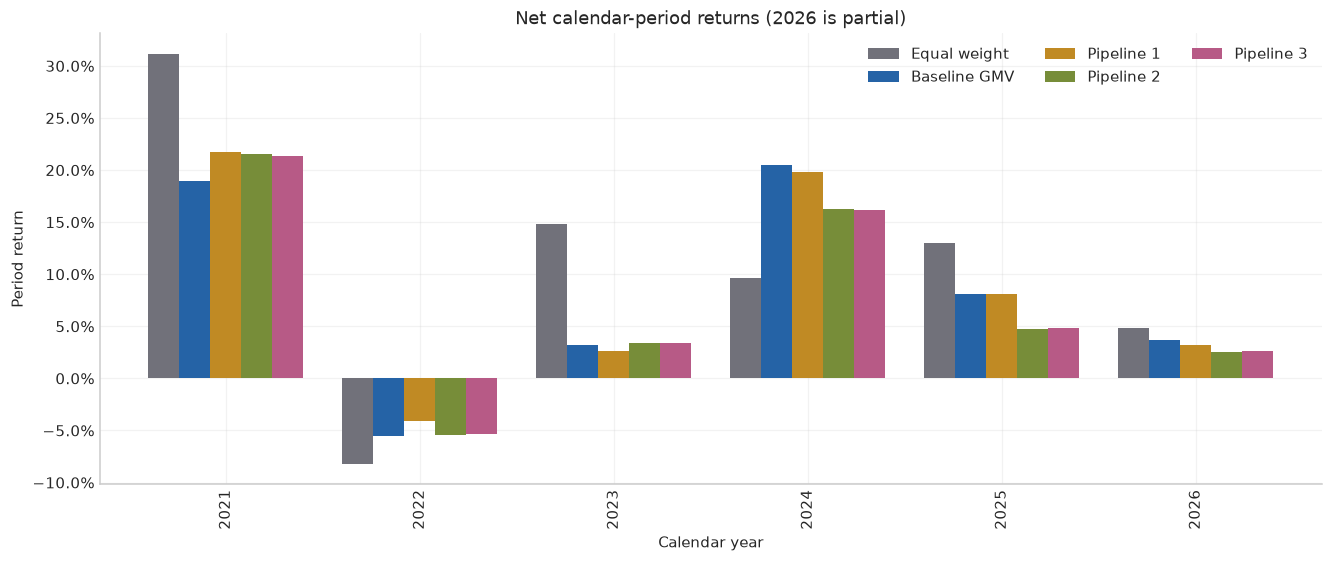

In [9]:
annual = annual_metrics(results)
annual.to_csv(ROOT / "artifacts/tables/comparison_annual_metrics.csv", index=False)
display(annual.pivot(index="year", columns="strategy", values="return").style.format("{:.2%}"))
fig, ax = plt.subplots(figsize=(12, 5), layout="constrained")
pivot = annual.pivot(index="year", columns="strategy", values="return").reindex(columns=list(LABELS))
pivot.rename(columns=LABELS).plot.bar(ax=ax, color=[COLORS[x] for x in LABELS], width=.8)
ax.set(title="Net calendar-period returns (2026 is partial)", ylabel="Period return", xlabel="Calendar year")
ax.yaxis.set_major_formatter(PercentFormatter(1));ax.legend(ncol=3)
save(fig, "comparison_annual_returns")

### Trading costs and forecast regimes

In [10]:
costs = cost_sensitivity(results)
display(styled(costs.set_index(["cost_bps", "strategy"])[["CAGR", "Sharpe", "CVaR 95%"]]))
conditional = regime_conditioned(results)
display(styled(conditional.set_index(["regime", "strategy"])))

,,CAGR,Sharpe,CVaR 95%
cost_bps,strategy,,,
0,equal_weight,12.20%,0.768,2.41%
10,equal_weight,12.11%,0.763,2.41%
25,equal_weight,11.97%,0.755,2.41%
50,equal_weight,11.74%,0.743,2.41%
0,baseline,9.52%,0.757,1.86%
10,baseline,9.16%,0.733,1.86%
25,baseline,8.63%,0.696,1.86%
50,baseline,7.76%,0.634,1.87%
0,pipeline1,10.15%,0.807,1.84%


,,days,Annualized Volatility,Sharpe,CVaR 95%
regime,strategy,,,,
Calm forecast,equal_weight,721.000,12.37%,0.514,1.81%
Stress forecast,equal_weight,568.000,21.21%,0.995,2.97%
Calm forecast,baseline,721.000,9.92%,0.877,1.38%
Stress forecast,baseline,568.000,16.36%,0.661,2.24%
Calm forecast,pipeline1,721.000,9.90%,0.934,1.40%
Stress forecast,pipeline1,568.000,16.18%,0.689,2.19%
Calm forecast,pipeline2,721.000,9.85%,0.680,1.38%
Stress forecast,pipeline2,568.000,16.33%,0.673,2.20%
Calm forecast,pipeline3,721.000,9.83%,0.671,1.38%


### Is the quality effect specific to company information?

The following **post-evaluation explanatory diagnostics** do not change the frozen settings. A neutral quality score of 0.5 applies the same form of diagonal regularization without ranking businesses. For the ML layer, historical downside risk replaces the learned forecast at the same selected strength. These controls help separate added information from the effect of adding any positive diagonal penalty; they are not independent confirmatory tests.

In [11]:
c = prepare_features(prepare_fundamentals(prepare_context()))
verify_frozen(c, spec)
neutral = c["fundamentals"].copy(); neutral["quality_score"] = .5
neutral_result = strategy({**c, "fundamentals": neutral}, "test", "pipeline2", spec["quality_strength"])
historical_predictions = pd.read_csv(ROOT / "artifacts/tables/pipeline3_test_predictions.csv", parse_dates=["date"])
historical_predictions["predicted_downside_variance"] = historical_predictions.downside_63
historical_result = strategy(c, "test", "pipeline3", spec["quality_strength"], historical_predictions, spec["ml"]["ml_strength"])
controls = {"Pipeline 1": results["pipeline1"], "Neutral diagonal penalty": neutral_result,
            "Quality penalty": results["pipeline2"], "Quality + historical downside": historical_result, "Quality + CatBoost": results["pipeline3"]}
control_table = metric_table(controls)
display(styled(control_table[METRIC_COLUMNS]))
control_table.to_csv(ROOT / "artifacts/tables/test_explanatory_controls.csv")
quality = c["fundamentals"].pivot(index="date", columns="ticker", values="quality_score")
quality_exposure = pd.Series({name: (r.target_weights*quality.reindex(r.target_weights.index)).sum(axis=1).mean() for name,r in results.items()}, name="average_weighted_quality")
display(quality_exposure.to_frame().style.format("{:.3f}"))

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
Pipeline 1,9.68%,13.04%,0.774,1.102,18.23%,1.84%,2.84%,4.297,11.585
Neutral diagonal penalty,7.99%,13.09%,0.653,0.926,17.69%,1.85%,2.88%,3.205,17.699
Quality penalty,8.04%,13.10%,0.656,0.932,17.88%,1.84%,2.88%,3.252,17.115
Quality + historical downside,8.06%,13.06%,0.659,0.936,17.59%,1.83%,2.86%,3.171,17.702
Quality + CatBoost,8.04%,13.08%,0.656,0.933,17.78%,1.83%,2.87%,3.179,17.628


,average_weighted_quality
equal_weight,0.507
baseline,0.512
pipeline1,0.512
pipeline2,0.528
pipeline3,0.527


### Does broader information improve the CatBoost model?

In [12]:
feature_ablations = {name: load_result("pipeline3_"+name, "test") for name in ["price_regime", "plus_fundamentals"]}
feature_ablations["full"] = results["pipeline3"]
display(styled(metric_table(feature_ablations)[METRIC_COLUMNS]))
forecast_rows=[]
for name in ["price_regime", "plus_fundamentals", "full"]:
    path = ROOT / ("artifacts/tables/pipeline3_test_predictions.csv" if name=="full" else f"artifacts/tables/ablation_{name}_test_predictions.csv")
    pred = pd.read_csv(path, parse_dates=["date"])
    forecast_rows.append(prediction_diagnostics(pred).loc["CatBoost"].rename(name))
forecast_table = pd.DataFrame(forecast_rows)
display(forecast_table)
forecast_table.to_csv(ROOT / "artifacts/tables/test_forecast_feature_ablation.csv")

,CAGR,Annualized Volatility,Sharpe,Sortino,Maximum Drawdown,CVaR 95%,CVaR 99%,Annualized Turnover,Average Effective Assets
price_regime,8.06%,13.09%,0.658,0.935,17.75%,1.83%,2.87%,3.178,17.632
plus_fundamentals,8.04%,13.09%,0.656,0.933,17.77%,1.83%,2.87%,3.177,17.627
full,8.04%,13.08%,0.656,0.933,17.78%,1.83%,2.87%,3.179,17.628


,rows,months,log_risk_RMSE,mean_monthly_rank_IC,median_monthly_rank_IC
price_regime,3050.0,61.0,0.873847,0.577307,0.571861
plus_fundamentals,3050.0,61.0,0.874931,0.577045,0.561873
full,3050.0,61.0,0.883598,0.580090,0.578872


## Takeaways

### Evidence-backed article storyline

In [13]:
b,p1,p2,p3=[test_table.loc[x] for x in ["baseline","pipeline1","pipeline2","pipeline3"]]
display(Markdown(f"""
1. **Start with a strong control.** Shrinkage GMV has {b['Annualized Volatility']:.2%} volatility versus {test_table.loc['equal_weight','Annualized Volatility']:.2%} for equal weighting, with a return trade-off.
2. **Market regimes change the dependence estimate.** Pipeline 1 delivers {p1['CAGR']:.2%} CAGR and a {p1['Sharpe']:.3f} Sharpe ratio; its risk changes are modest and turnover is higher.
3. **Corporate-quality regularization changes portfolio structure.** Pipeline 2 raises effective breadth from {p1['Average Effective Assets']:.2f} to {p2['Average Effective Assets']:.2f} and lowers annual turnover from {p1['Annualized Turnover']:.2f} to {p2['Annualized Turnover']:.2f}. Its CAGR falls to {p2['CAGR']:.2%}; slight tail-risk improvements are insufficient to claim universal dominance. Check the neutral-penalty control before attributing the whole effect to fundamentals.
4. **Better forecasts have limited allocation value here.** Pipeline 3 has {p3['Annualized Volatility']:.2%} volatility and {p3['CVaR 95%']:.2%} daily CVaR95. Its incremental changes relative to Pipeline 2 are small. Feature ablations and prediction diagnostics explain whether the added information affects forecasts, weights, or both.
5. **The conclusion is conditional.** This study supports an incremental experimental framework, not a guaranteed improvement from adding features. Sector-aware quality, a broader historical constituent universe, validated corporate-action data, realistic execution delays and a fresh forward holdout are the next research priorities.
"""))
print("All primary result paths reconciled; use these tables instead of mixing old validation and test numbers.")


1. **Start with a strong control.** Shrinkage GMV has 13.15% volatility versus 16.85% for equal weighting, with a return trade-off.
2. **Market regimes change the dependence estimate.** Pipeline 1 delivers 9.68% CAGR and a 0.774 Sharpe ratio; its risk changes are modest and turnover is higher.
3. **Corporate-quality regularization changes portfolio structure.** Pipeline 2 raises effective breadth from 11.59 to 17.12 and lowers annual turnover from 4.30 to 3.25. Its CAGR falls to 8.04%; slight tail-risk improvements are insufficient to claim universal dominance. Check the neutral-penalty control before attributing the whole effect to fundamentals.
4. **Better forecasts have limited allocation value here.** Pipeline 3 has 13.08% volatility and 1.83% daily CVaR95. Its incremental changes relative to Pipeline 2 are small. Feature ablations and prediction diagnostics explain whether the added information affects forecasts, weights, or both.
5. **The conclusion is conditional.** This study supports an incremental experimental framework, not a guaranteed improvement from adding features. Sector-aware quality, a broader historical constituent universe, validated corporate-action data, realistic execution delays and a fresh forward holdout are the next research priorities.


## Sources and methodological references

- Original local source notebooks: `price_EDA.ipynb`, `company_analisys.ipynb`; draft manuscript: `Portfolio optimization.docx`.
- [Kaggle price snapshot, version 1](https://www.kaggle.com/datasets/jacksaleeby/s-and-p500-historical-data): original selection and saved splits are preserved. The provider's `Adj Close` is used as supplied; dividend/corporate-action adjustment quality is not independently certified.
- [SEC EDGAR XBRL API documentation](https://www.sec.gov/search-filings/edgar-application-programming-interfaces), [SEC identity reference](https://www.sec.gov/files/company_tickers_exchange.json). Identity reference data are used only to link issuers, not as historical predictive features.
- [CatBoost training parameters](https://catboost.ai/docs/en/references/training-parameters/common), [regression objectives](https://catboost.ai/docs/en/concepts/loss-functions-regression).
- Markowitz (1952), Ledoit & Wolf (2004), Hamilton (1989), Asness et al. (2019), Prokhorenkova et al. (2018): conceptual sources cited in the manuscript. The bespoke feature score and optimization penalties here are experimental implementations, not replicas of those papers.